In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("../Datos en bruto/Malaria/ECDC_surveillance_data_Malaria.csv", sep=",")
data

,HealthTopic,Population,Indicator,Unit,Time,RegionCode,RegionName,NumValue,TxtValue
0,Malaria,Confirmed cases,Notification rate,N/100000,2008-01,AT,Austria,0.000000000,NaN
1,Malaria,Confirmed cases,Notification rate,N/100000,2008-01,BE,Belgium,0.000000000,NaN
2,Malaria,Confirmed cases,Notification rate,N/100000,2008-01,BG,Bulgaria,0.000000000,NaN
3,Malaria,Confirmed cases,Notification rate,N/100000,2008-01,CY,Cyprus,0.000000000,NaN
4,Malaria,Confirmed cases,Notification rate,N/100000,2008-01,CZ,Czechia,0.048339900,NaN
...,...,...,...,...,...,...,...,...,...
24999,Malaria,Confirmed cases - Data quality,Completeness Gender - AER Only (not visible in...,%,2023-12,PT,Portugal,100.000000000,NaN
25000,Malaria,Confirmed cases - Data quality,Completeness Gender - AER Only (not visible in...,%,2023-12,RO,Romania,100.000000000,NaN
25001,Malaria,Confirmed cases - Data quality,Completeness Gender - AER Only (not visible in...,%,2023-12,SE,Sweden,100.000000000,NaN
25002,Malaria,Confirmed cases - Data quality,Completeness Gender - AER Only (not visible in...,%,2023-12,SI,Slovenia,100.000000000,NaN


In [4]:
malaria_ESP=data[(data.Indicator=='Reported cases') & (data.RegionName=='Spain')]

In [5]:
malaria_ESP['Time'] = pd.to_datetime(malaria_ESP['Time'])
malaria_ESP['NumValue'] = pd.to_numeric(malaria_ESP['NumValue'])

In [6]:
malaria_ESP=malaria_ESP.loc[:,['Time','NumValue']]
malaria_ESP.set_index('Time', inplace=True)
malaria_ESP

,NumValue
Time,
2008-01-01,17.0
2008-02-01,12.0
2008-03-01,13.0
2008-04-01,12.0
2008-05-01,16.0
...,...
2023-08-01,109.0
2023-09-01,123.0
2023-10-01,130.0


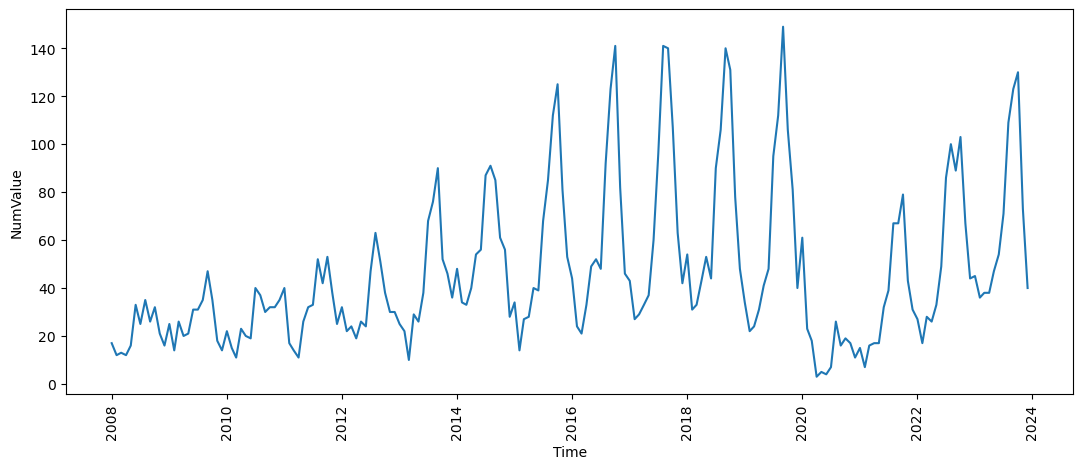

In [7]:
plt.figure(figsize=(13,5))
sns.lineplot(data=malaria_ESP,x=malaria_ESP.index,y=malaria_ESP.NumValue)
plt.xticks(rotation=90)
plt.show()

In [8]:
#Exportamos los datos relativos al 
malaria_ESP.to_csv('malaria_esp_indexado.csv',index=True,encoding='utf-8')